# 1 — Meta-evaluating the judge

Week 2's bake-off surfaced a meta-finding: the rubric **judge** has its own opinions. It punished honest "I couldn't search" answers ~2 points below honest "I searched and found nothing" answers (same epistemic position). It dinged verbose, well-cited answers in favor of terse ones. It rewarded confidence over hedging.

Here we treat the judge as the system under test.

## Setup

- **Gold set**: 16 hand-crafted `(question, answer, expected_range)` items in `data/judge_gold_set.jsonl`, organized into 6 probe categories (ground-truth sanity, honesty vs. fabrication, format vs. verbosity, citations, refusal-mode equivalence, tone vs. correctness).
- **Sweep**: each item is judged by every model in `JUDGE_MODELS`. We record `overall`, `correctness`, `faithfulness` plus latency.
- **Output**: agreement-with-human table, per-probe agreement, detail pivot.

## What "agreement" means here

The human-supplied `expected_overall_min/max` is a **band**, not a target. A judge agrees on an item when its `overall` falls inside that band. Across items we report:
- `agreement_pct` — fraction of items where the judge fell inside the band.
- `mae_to_band` — mean absolute distance to the nearest band edge (0 if inside).
- `bias_signed` — mean signed distance to band midpoint (positive = judge over-scores vs. humans).

Resume-safe: the sweep cell appends to `data/judge_eval_results.csv` keyed on `(judge_model, item_id)` and skips rows that already exist.

In [5]:
import _path_setup  # noqa: F401

import json
import time
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from judges import judge_with_rubric  # type: ignore
from llm import get_llm  # type: ignore

DATA = Path("data")
GOLD = DATA / "judge_gold_set.jsonl"
RESULTS_CSV = DATA / "judge_eval_results.csv"

items = [json.loads(l) for l in GOLD.read_text().splitlines() if l.strip()]
print(f"Loaded {len(items)} gold items across {len({i['probe'] for i in items})} probes:")
for probe in sorted({i['probe'] for i in items}):
    n = sum(1 for i in items if i['probe'] == probe)
    print(f"  {probe:<32s} ({n})")

Loaded 32 gold items across 8 probes:
  citation_presence                (4)
  format_vs_verbosity              (3)
  ground_truth_sanity              (6)
  honesty_vs_fabrication           (6)
  length_bias                      (3)
  refusal_mode_equivalence         (4)
  specificity                      (2)
  tone_vs_correctness              (4)


In [6]:
# Sweep across vendors and capability tiers. Cheap-and-fast first so a partial
# run still gives a useful comparison if you Ctrl-C the sweep cell.
JUDGE_MODELS = [
    # OpenAI
    "openai/gpt-5.4-nano",
    "openai/gpt-5.4-mini",
    "openai/gpt-5.5",
    # Anthropic
    "anthropic/claude-haiku-4.5",
    "anthropic/claude-sonnet-4.6",
    "anthropic/claude-opus-4.7",
    # Google
    "google/gemini-2.5-flash-lite",
    "google/gemini-2.5-flash",
    "google/gemini-2.5-pro",
    # Open weights
    "qwen/qwen3.6-35b-a3b",
    "qwen/qwen3.6-max-preview",
    "moonshotai/kimi-k2.6",
    "deepseek/deepseek-v4-pro",
]
print(f"{len(JUDGE_MODELS)} judge models x {len(items)} items = {len(JUDGE_MODELS)*len(items)} calls")

13 judge models x 32 items = 416 calls


In [7]:
# Resume-safe sweep. Re-running this cell after a partial run only fills in
# the missing (judge_model, item_id) pairs.
if RESULTS_CSV.exists():
    df_done = pd.read_csv(RESULTS_CSV)
    done = set(zip(df_done['judge_model'], df_done['item_id']))
    print(f"Resuming: {len(done)} cells already done.")
else:
    df_done = pd.DataFrame(columns=[
        'judge_model','item_id','probe','expected_lo','expected_hi',
        'overall','correctness','faithfulness','latency_s','error',
    ])
    done = set()

rows = []
for slug in JUDGE_MODELS:
    judge_llm = get_llm(slug)
    for it in items:
        key = (slug, it['id'])
        if key in done:
            continue
        t0 = time.time()
        try:
            rb = judge_with_rubric(
                question=it['question'],
                answer=it['answer'],
                reference=it.get('reference') or '',
                evidence=it.get('evidence'),
                judge_llm=judge_llm,
            )
            row = {
                'judge_model': slug, 'item_id': it['id'], 'probe': it['probe'],
                'expected_lo': it['expected_overall_min'], 'expected_hi': it['expected_overall_max'],
                'overall': rb.overall, 'correctness': rb.correctness, 'faithfulness': rb.faithfulness,
                'latency_s': round(time.time() - t0, 2), 'error': '',
            }
        except Exception as e:
            row = {
                'judge_model': slug, 'item_id': it['id'], 'probe': it['probe'],
                'expected_lo': it['expected_overall_min'], 'expected_hi': it['expected_overall_max'],
                'overall': None, 'correctness': None, 'faithfulness': None,
                'latency_s': round(time.time() - t0, 2), 'error': f'{type(e).__name__}: {e}'[:200],
            }
        rows.append(row)
        # Append-after-each-call so a Ctrl-C is safe.
        pd.DataFrame([row]).to_csv(
            RESULTS_CSV, mode='a', header=not RESULTS_CSV.exists(), index=False,
        )
        flag = '  ' if (row['overall'] is not None
                        and row['expected_lo'] <= row['overall'] <= row['expected_hi']) else '!!'
        score = f"{row['overall']:.2f}" if row['overall'] is not None else 'ERR'
        print(f"{flag} {slug:<32s} {it['id']:<32s} "
              f"exp {row['expected_lo']}-{row['expected_hi']}  judge={score}")

print(f"\nWrote {len(rows)} new rows to {RESULTS_CSV}")

   openai/gpt-5.4-nano              A1_correct_easy                  exp 4.3-5.0  judge=4.80
   openai/gpt-5.4-nano              A2_confidently_wrong             exp 0.0-1.5  judge=0.00
!! openai/gpt-5.4-nano              A3_partial_correct               exp 2.0-3.0  judge=3.80
   openai/gpt-5.4-nano              A4_empty                         exp 0.0-1.5  judge=0.00
   openai/gpt-5.4-nano              B1_honest_no_corpus              exp 4.5-5.0  judge=4.80
   openai/gpt-5.4-nano              B2_fabricated_plausible          exp 0.0-1.5  judge=0.00
   openai/gpt-5.4-nano              B3_lazy_idk                      exp 1.5-2.5  judge=1.62
   openai/gpt-5.4-nano              C1_tight_correct                 exp 4.3-5.0  judge=5.00
   openai/gpt-5.4-nano              C2_verbose_correct               exp 4.3-5.0  judge=4.80
!! openai/gpt-5.4-nano              C3_padded_filler                 exp 4.0-4.8  judge=4.90
   openai/gpt-5.4-nano              D1_with_citations                e

In [8]:
df = pd.read_csv(RESULTS_CSV)
df = df[df['error'].fillna('') == ''].copy()

df['midpoint'] = (df['expected_lo'] + df['expected_hi']) / 2
df['in_band'] = (df['overall'] >= df['expected_lo']) & (df['overall'] <= df['expected_hi'])
df['signed_dev'] = df['overall'] - df['midpoint']
df['dist_to_band'] = df.apply(
    lambda r: 0.0 if r['in_band'] else min(abs(r['overall'] - r['expected_lo']),
                                           abs(r['overall'] - r['expected_hi'])),
    axis=1,
)
print(f"{len(df)} judged cells across {df['judge_model'].nunique()} models, {df['item_id'].nunique()} items")

384 judged cells across 12 models, 32 items


,n,agreement_pct,mae_to_band,bias_signed,mean_latency_s
judge_model,,,,,
anthropic/claude-sonnet-4.6,32,84.4,0.05,-0.05,4.69
anthropic/claude-haiku-4.5,32,81.2,0.07,-0.02,3.41
google/gemini-2.5-pro,32,81.2,0.17,0.21,10.82
deepseek/deepseek-v4-pro,32,78.1,0.12,0.28,24.54
openai/gpt-5.4-mini,32,78.1,0.10,0.05,1.58
moonshotai/kimi-k2.6,32,75.0,0.14,0.20,117.12
openai/gpt-5.5,32,75.0,0.16,0.37,2.63
qwen/qwen3.6-35b-a3b,32,75.0,0.17,0.09,17.74
anthropic/claude-opus-4.7,32,71.9,0.11,0.20,3.67


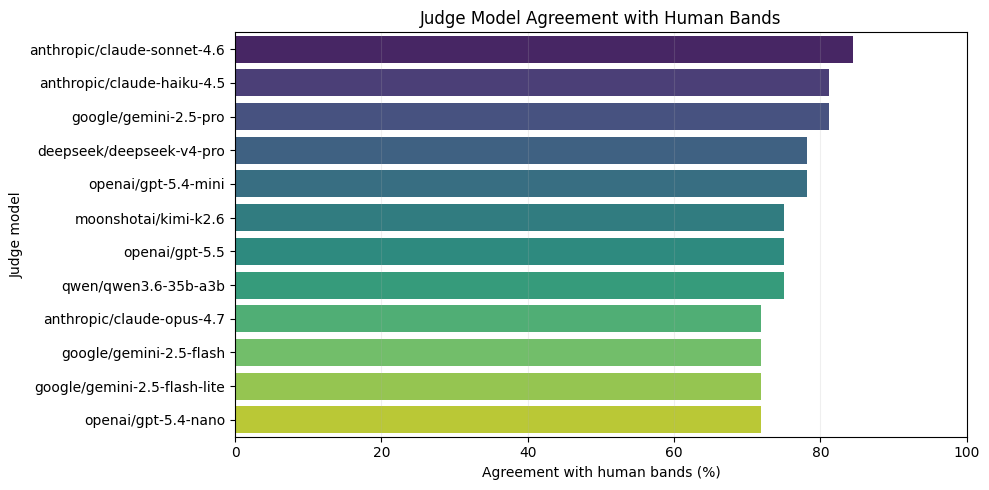

In [18]:
# Headline table: how well does each judge model agree with the human bands?
agreement = (df.groupby('judge_model')
               .agg(n=('item_id', 'count'),
                    agreement_pct=('in_band', 'mean'),
                    mae_to_band=('dist_to_band', 'mean'),
                    bias_signed=('signed_dev', 'mean'),
                    mean_latency_s=('latency_s', 'mean'))
               .assign(agreement_pct=lambda d: (d['agreement_pct'] * 100).round(1))
               .round(2)
               .sort_values('agreement_pct', ascending=False))
display(agreement)

# --- Bar graph: Agreement percent by judge model ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=agreement.reset_index(), 
    x='agreement_pct', 
    y='judge_model', 
    hue='judge_model',
    order=agreement.index,
    palette='viridis',
    legend=False
)
plt.xlabel('Agreement with human bands (%)')
plt.ylabel('Judge model')
plt.title('Judge Model Agreement with Human Bands')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

### Better metrics: Cohen's κ, QWK, Spearman ρ

Plain `agreement_pct` only counts exact band hits — a 3→4 miss looks the same as a 3→1 miss. We want more nuance.

**Cohen's κ** — agreement *minus what chance would give you*. Range −1…1.
- Example: human says "3" 60% of the time → a random judge agrees 36% by luck. κ subtracts that.
- Treats every miss as equally bad, so it's harsh on ordinal scores.

**Quadratic-weighted κ (QWK)** — same idea, but a 1-band miss costs 1, a 2-band miss costs 4, a 3-band miss costs 9.
- Example: judge A goes 3→4 every time it errs. Judge B goes 3→1 every time it errs. Both have the same `agreement_pct`. QWK ranks A way ahead.
- This is the gold-standard metric for ordinal LLM-judge eval (Kaggle essay scoring, AlpacaEval, etc.). **It's the headline.**

**Spearman ρ** — does the judge at least *rank* items in the same order?
- Example: judge always scores +1 high (3→4, 4→5). Bad on agreement, but ρ = 1.0 because the order is preserved. Useful for "A vs B" tasks.

**`bias_signed`** — average direction of error. +0.3 = "always too generous." Tells you whether a judge is *miscalibrated* or just *noisy*.

| Want to know… | Look at |
|---|---|
| Hits the right bucket? | `agreement_pct` |
| Better than chance? | Cohen's κ |
| Misses are small AND not chance? | **QWK** |
| Ranks correctly? | Spearman ρ |
| Systematically too high/low? | `bias_signed` |

QWK ≥ 0.8 → trust it. 0.6–0.8 → usable. < 0.6 → recalibrate or replace.

,n,agreement_pct,cohen_kappa,qwk,spearman_rho,bias_signed
judge_model,,,,,,
anthropic/claude-haiku-4.5,32,81.2,0.583,0.932,0.878,-0.02
anthropic/claude-sonnet-4.6,32,84.4,0.554,0.924,0.752,-0.05
deepseek/deepseek-v4-pro,32,78.1,0.534,0.923,0.808,0.28
anthropic/claude-opus-4.7,32,71.9,0.499,0.915,0.845,0.20
openai/gpt-5.4-mini,32,78.1,0.531,0.914,0.802,0.05
qwen/qwen3.6-35b-a3b,32,75.0,0.534,0.879,0.809,0.09
openai/gpt-5.5,32,75.0,0.437,0.875,0.778,0.37
moonshotai/kimi-k2.6,32,75.0,0.536,0.873,0.854,0.20
google/gemini-2.5-flash-lite,32,71.9,0.414,0.870,0.849,-0.27


/var/folders/y9/9xqbqkg90tnc0cmm0dxt985m0000gn/T/ipykernel_47478/2626975785.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


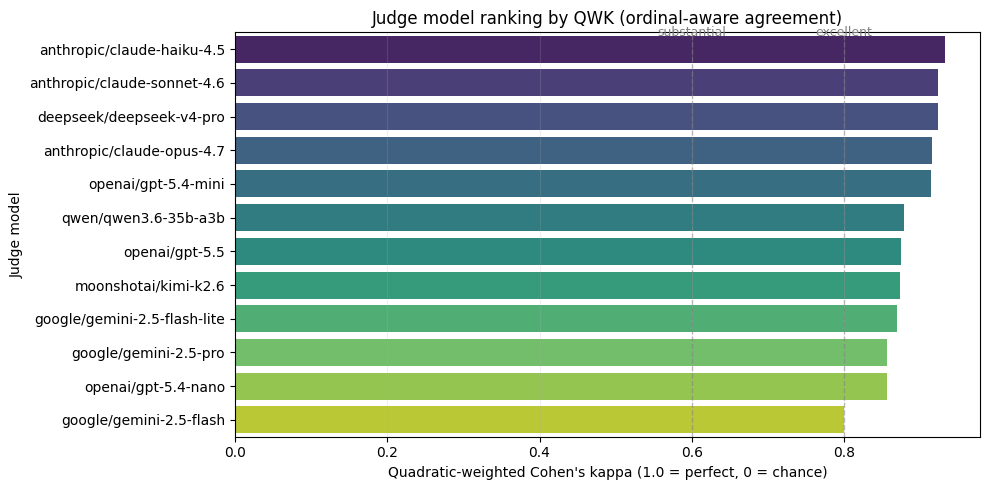

In [19]:
# Chance-corrected agreement: Cohen's kappa, quadratic-weighted kappa, Spearman rho.
#
# Plain `agreement_pct` doesn't tell us whether a judge is right for the right
# reason. With ordinal bands, the standard fix is **quadratic-weighted kappa
# (QWK)** — it punishes "off by 3 bands" much more than "off by 1," which is
# what we actually care about.
#
# We discretize judge `overall` and the human band midpoint to nearest integer
# on the 1-5 rubric scale and compare. Spearman is added as a pure-ranking
# companion (insensitive to systematic +/- bias).

from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr
import numpy as np

def _to_band(x):
    """Snap continuous score to integer band on the 1..5 rubric scale."""
    return int(np.clip(round(float(x)), 1, 5))

scored = df.copy()
scored["judge_band"] = scored["overall"].apply(_to_band)
scored["human_band"] = scored["midpoint"].apply(_to_band)

rows = []
for slug, g in scored.groupby("judge_model"):
    h, j = g["human_band"].to_numpy(), g["judge_band"].to_numpy()
    rho, _ = spearmanr(g["overall"], g["midpoint"])
    rows.append({
        "judge_model": slug,
        "n": len(g),
        "agreement_pct": round(g["in_band"].mean() * 100, 1),
        "cohen_kappa": round(cohen_kappa_score(h, j), 3),
        "qwk": round(cohen_kappa_score(h, j, weights="quadratic"), 3),
        "spearman_rho": round(rho if rho == rho else 0.0, 3),  # NaN -> 0 if all ties
        "bias_signed": round(g["signed_dev"].mean(), 2),
    })

kappa_table = (pd.DataFrame(rows)
                 .set_index("judge_model")
                 .sort_values("qwk", ascending=False))
display(kappa_table)

# Re-rank the bar chart by QWK so the visual matches the metric that matters
# for an ordinal judge.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=kappa_table.reset_index(),
    x="qwk",
    y="judge_model",
    order=kappa_table.index,
    palette="viridis",
)
plt.xlabel("Quadratic-weighted Cohen's kappa (1.0 = perfect, 0 = chance)")
plt.ylabel("Judge model")
plt.title("Judge model ranking by QWK (ordinal-aware agreement)")
plt.axvline(0.6, color="grey", linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(0.8, color="grey", linestyle="--", linewidth=1, alpha=0.5)
plt.text(0.6, -0.4, "substantial", color="grey", fontsize=9, ha="center")
plt.text(0.8, -0.4, "excellent",   color="grey", fontsize=9, ha="center")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
# Where does each judge agree or disagree? Heatmap-style pivot of agreement %.
by_probe = (df.groupby(['judge_model', 'probe'])['in_band'].mean()
              .mul(100).round(0)
              .unstack('probe')
              .fillna(-1)
              .astype(int))
by_probe.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=100, axis=None) \
             .format('{:.0f}%') \
             .set_caption('Agreement % by judge model x probe (green = agrees with humans)')

probe,citation_presence,format_vs_verbosity,ground_truth_sanity,honesty_vs_fabrication,length_bias,refusal_mode_equivalence,specificity,tone_vs_correctness
judge_model,,,,,,,,
anthropic/claude-haiku-4.5,50%,100%,83%,100%,100%,50%,50%,100%
anthropic/claude-opus-4.7,50%,100%,67%,67%,100%,50%,50%,100%
anthropic/claude-sonnet-4.6,50%,100%,100%,100%,67%,50%,100%,100%
deepseek/deepseek-v4-pro,50%,100%,67%,83%,100%,75%,50%,100%
google/gemini-2.5-flash,75%,100%,67%,67%,67%,50%,50%,100%
google/gemini-2.5-flash-lite,0%,100%,100%,67%,100%,50%,50%,100%
google/gemini-2.5-pro,50%,100%,83%,100%,100%,50%,50%,100%
moonshotai/kimi-k2.6,50%,100%,67%,83%,100%,50%,50%,100%
openai/gpt-5.4-mini,50%,100%,83%,83%,100%,75%,50%,75%


In [11]:
# Same pivot but showing the SIGNED deviation: positive = judge over-scores vs. our midpoint.
# This is the diagnostic plot: for each probe, are judges systematically generous or harsh?
bias_pivot = (df.groupby(['judge_model', 'probe'])['signed_dev'].mean()
                .unstack('probe')
                .round(2))
bias_pivot.style.background_gradient(cmap='RdBu_r', vmin=-2.5, vmax=2.5, axis=None) \
                .format('{:+.2f}') \
                .set_caption('Signed deviation from human midpoint (red = judge too generous, blue = too harsh)')

probe,citation_presence,format_vs_verbosity,ground_truth_sanity,honesty_vs_fabrication,length_bias,refusal_mode_equivalence,specificity,tone_vs_correctness
judge_model,,,,,,,,
anthropic/claude-haiku-4.5,+0.26,+0.13,-0.01,-0.21,+0.10,-0.50,+0.68,-0.09
anthropic/claude-opus-4.7,+0.45,+0.20,+0.29,+0.35,+0.15,-0.45,+0.60,+0.04
anthropic/claude-sonnet-4.6,+0.45,-0.00,+0.08,-0.32,-0.08,-0.55,+0.30,-0.03
deepseek/deepseek-v4-pro,+0.40,+0.30,+0.66,+0.14,+0.28,-0.30,+0.80,+0.12
google/gemini-2.5-flash,+0.20,+0.03,-0.28,-0.73,-0.18,-1.05,+1.00,-0.03
google/gemini-2.5-flash-lite,-0.03,+0.17,-0.34,-0.50,-0.12,-0.88,+0.50,-0.28
google/gemini-2.5-pro,+0.50,+0.18,+0.51,+0.12,+0.10,-0.94,+0.97,+0.45
moonshotai/kimi-k2.6,+0.40,+0.30,+0.56,+0.08,+0.28,-0.60,+0.90,-0.03
openai/gpt-5.4-mini,+0.52,+0.37,+0.17,-0.46,+0.28,-0.43,+1.00,-0.23


In [12]:
# Per-item detail: model x item with the expected band shown alongside.
wide = df.pivot_table(index='item_id', columns='judge_model', values='overall').round(2)
bands = (df.groupby('item_id')[['expected_lo', 'expected_hi']].first())
detail = bands.join(wide)

def _color(val, lo, hi):
    if pd.isna(val):
        return ''
    if lo <= val <= hi:
        return 'background-color: #d4edda'  # green
    return 'background-color: #f8d7da'  # red

def _style(row):
    lo, hi = row['expected_lo'], row['expected_hi']
    return ['', '', *[_color(row[m], lo, hi) for m in JUDGE_MODELS if m in row.index]]

detail.style.apply(_style, axis=1).format('{:.2f}', na_rep='—') \
            .set_caption('Per-item scores (green = inside expected band)')

,expected_lo,expected_hi,anthropic/claude-haiku-4.5,anthropic/claude-opus-4.7,anthropic/claude-sonnet-4.6,deepseek/deepseek-v4-pro,google/gemini-2.5-flash,google/gemini-2.5-flash-lite,google/gemini-2.5-pro,moonshotai/kimi-k2.6,openai/gpt-5.4-mini,openai/gpt-5.4-nano,openai/gpt-5.5,qwen/qwen3.6-35b-a3b
item_id,,,,,,,,,,,,,,
A1_correct_easy,4.30,5.00,4.75,4.80,4.90,5.00,3.20,4.50,5.00,4.80,5.00,4.80,5.00,5.00
A2_confidently_wrong,0.00,1.50,0.00,0.60,0.40,1.00,0.00,0.00,1.25,0.80,0.40,0.00,0.80,0.20
A3_partial_correct,2.00,3.00,3.40,3.25,2.50,4.40,3.80,2.50,4.25,4.40,3.25,3.80,4.00,4.20
A4_empty,0.00,1.50,0.62,1.67,1.25,2.00,0.00,0.00,0.60,2.00,1.00,0.00,2.00,1.00
A5_correct_chunking,4.30,5.00,4.80,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,4.90,5.00,5.00
A6_wrong_ndcg,0.00,1.50,0.40,0.50,0.50,0.60,0.40,0.00,1.00,0.40,0.40,0.00,0.60,0.75
B1_honest_no_corpus,4.50,5.00,4.75,4.83,4.50,4.80,4.60,5.00,5.00,4.80,4.80,4.80,4.80,4.80
B2_fabricated_plausible,0.00,1.50,0.00,0.60,0.40,0.80,0.00,0.00,1.25,0.40,0.20,0.00,0.50,0.20
B3_lazy_idk,1.50,2.50,2.50,3.60,1.50,3.00,0.80,1.25,2.00,2.20,1.20,1.62,3.60,2.40


In [13]:
# Spotlight on the bake-off bias: refusal_mode_equivalence (E1 vs E2).
# Both honest, same conclusion. A faithful judge should score them within ~0.5.
e = df[df['probe'] == 'refusal_mode_equivalence'].pivot_table(
    index='judge_model', columns='item_id', values='overall',
)
e['delta_E1_minus_E2'] = (e['E1_searched_found_nothing'] - e['E2_could_not_search']).round(2)
e.round(2).sort_values('delta_E1_minus_E2', ascending=False)

item_id,E1_searched_found_nothing,E2_could_not_search,E3_searched_hyde,E4_could_not_search_hyde,delta_E1_minus_E2
judge_model,,,,,
google/gemini-2.5-flash-lite,5.0,1.0,5.0,2.50,4.0
google/gemini-2.5-flash,5.0,1.4,5.0,1.40,3.6
openai/gpt-5.4-nano,5.0,1.5,4.7,1.00,3.5
qwen/qwen3.6-35b-a3b,5.0,1.6,5.0,2.40,3.4
google/gemini-2.5-pro,5.0,2.0,5.0,1.25,3.0
moonshotai/kimi-k2.6,5.0,2.2,5.0,2.40,2.8
anthropic/claude-haiku-4.5,5.0,2.4,5.0,2.60,2.6
anthropic/claude-opus-4.7,5.0,2.6,5.0,2.60,2.4
deepseek/deepseek-v4-pro,4.8,2.6,4.8,3.60,2.2


In [14]:
# Spotlight on honesty vs fabrication: B1 (honest+searched) vs B2 (fabricated+plausible).
# A faithful judge should score B1 >> B2. If a model scores B2 >= B1, it rewards fabrication.
b = df[df['probe'] == 'honesty_vs_fabrication'].pivot_table(
    index='judge_model', columns='item_id', values='overall',
)
b['delta_B1_minus_B2'] = (b['B1_honest_no_corpus'] - b['B2_fabricated_plausible']).round(2)
b.round(2).sort_values('delta_B1_minus_B2', ascending=False)

item_id,B1_honest_no_corpus,B2_fabricated_plausible,B3_lazy_idk,B4_honest_searched_graphrag,B5_fabricated_graphrag,B6_lazy_idk_graphrag,delta_B1_minus_B2
judge_model,,,,,,,
google/gemini-2.5-flash-lite,5.00,0.00,1.25,5.00,0.0,0.5,5.00
openai/gpt-5.4-nano,4.80,0.00,1.62,4.90,0.0,0.0,4.80
anthropic/claude-haiku-4.5,4.75,0.00,2.50,4.75,0.0,1.5,4.75
google/gemini-2.5-flash,4.60,0.00,0.80,5.00,0.0,0.0,4.60
openai/gpt-5.4-mini,4.80,0.20,1.20,4.80,0.0,1.0,4.60
qwen/qwen3.6-35b-a3b,4.80,0.20,2.40,4.80,0.2,0.6,4.60
moonshotai/kimi-k2.6,4.80,0.40,2.20,4.80,0.4,2.6,4.40
openai/gpt-5.5,4.80,0.50,3.60,4.80,0.4,3.2,4.30
anthropic/claude-opus-4.7,4.83,0.60,3.60,4.83,0.4,2.6,4.23


## How to read these tables

- **`agreement` table** — single number per judge: `agreement_pct` is the fraction of items where the judge fell inside the human band. `bias_signed` tells you the *direction* of disagreement (positive = generous, negative = harsh).
- **`by_probe` heatmap** — green cells show probes where this judge matches human intuition. Red cells are bias hotspots; in particular, watch `honesty_vs_fabrication` and `refusal_mode_equivalence`.
- **`bias_pivot`** — same axes, shows the *signed* gap. A column that's deep red across every model is a probe where **all judges agree with each other and disagree with us** — that's a place where our human prior is the thing being challenged, not the judge.
- **`E1 - E2` delta** — should be small (< 0.5). Larger values reproduce the bake-off bias.
- **`B1 - B2` delta** — should be **large and positive** (B1 is honest, B2 is fabrication). A small or negative value means that judge rewards fabrication.

## Next steps

- Add the **length / register** probes suggested in the README to expand the gold set.
- Use `bias_pivot` to pick the cheapest model whose biases match Opus 4.7. That's your production judge.
- See the next notebook for **DSPy-based prompt optimization of the judge** — using this gold set as the optimization target.